<a href="https://colab.research.google.com/github/PetrosAndarige/Pandas_Food_Delivery_Data_Analysis_Project/blob/main/PYF_Project_Learner_Notebook_Full_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [59]:
# Installing the libraries with the specified version.
#!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

!pip install numpy pandas matplotlib seaborn -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [60]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

### Understanding the structure of the data

In [61]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
# Write your code here to read the data
data = pd.read_csv("/content/drive/MyDrive/Python Course/Project/foodhub_order.csv")

In [63]:
# Write your code here to view the first 5 rows
data.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [64]:
# Write your code here
data.shape

(1898, 9)

#### Observations:


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [65]:
# Write your code here
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [66]:
# Write your code here
# pd.DataFrame({'Count':data.isnull().sum()[data.isnull().sum()>0],'Percentage':(data.isnull().sum()[data.isnull().sum()>0]/data.shape[0])*100})
pd.DataFrame({"Count":data.isnull().sum()})
data['rating'] = data['rating'].replace(['Not given'],np.nan).astype(float)

data


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.0,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.0,25,24
...,...,...,...,...,...,...,...,...,...
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5.0,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5.0,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,NaN,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5.0,23,31


#### Observations:


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [67]:
# Write your code here
data.describe()

,order_id,customer_id,cost_of_the_order,rating,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1162.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,4.344234,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,0.741478,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,3.000000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,4.000000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,5.000000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,5.000000,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,5.000000,35.000000,33.000000


#### Observations:


### **Question 5:** How many orders are not rated? [1 mark]

In [68]:
# Write the code here
len(data['rating'][data['rating'] == "Not given"])

0

#### Observations:


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

<Axes: xlabel='delivery_time', ylabel='Count'>

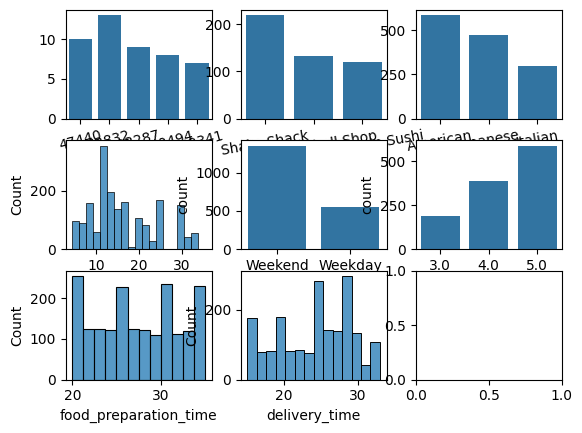

In [69]:
# Write the code here
fig, axes = plt.subplots(3, 3)

top_cust = data['customer_id'].value_counts().nlargest(5)
sns.barplot(x=top_cust.index, y=top_cust.values,   ax=axes[0, 0])
axes[0, 0].tick_params(axis='x', rotation=15)

top_rest = data['restaurant_name'].value_counts().nlargest(3)
sns.barplot(x=top_rest.index, y=top_rest.values, ax=axes[0,1])
axes[0, 1].tick_params(axis='x', rotation=10)

top_cuisine = data['cuisine_type'].value_counts().nlargest(3)
sns.barplot(x=top_cuisine.index, y=top_cuisine.values, ax=axes[0,2])
axes[0, 2].tick_params(axis='x', rotation=10)

sns.histplot(data=data,x='cost_of_the_order', ax= axes[1,0])

sns.countplot(data=data,x='day_of_the_week', ax=axes[1,1])

sns.countplot(data=data,x='rating', ax=axes[1,2])

sns.histplot(data=data,x='food_preparation_time', ax= axes[2,0])

sns.histplot(data=data,x='delivery_time', ax= axes[2,1])

# top_cuisine = data['cuisine_name'].value_counts().nlargest(3)
# sns.barplot(x=top_rest.index, y=top_rest.values, ax=axes[0,1])
# axes[0, 1].tick_params(axis='x', rotation=10)

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [70]:
# Write the code here
data['restaurant_name'].value_counts().nlargest(5)

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [71]:
# Write the code here
data[data['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts().nlargest(1)

,count
cuisine_type,
American,415


#### Observations:


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [72]:
# Write the code here
len(data[data['cost_of_the_order'] > 20])/len(data) * 100

29.24130663856691

#### Observations:


### **Question 10**: What is the mean order delivery time? [1 mark]

In [73]:
# Write the code here
data["delivery_time"].mean()

np.float64(24.161749209694417)

#### Observations:


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [74]:
# Write the code here
data["customer_id"].value_counts().nlargest(3)

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations:


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


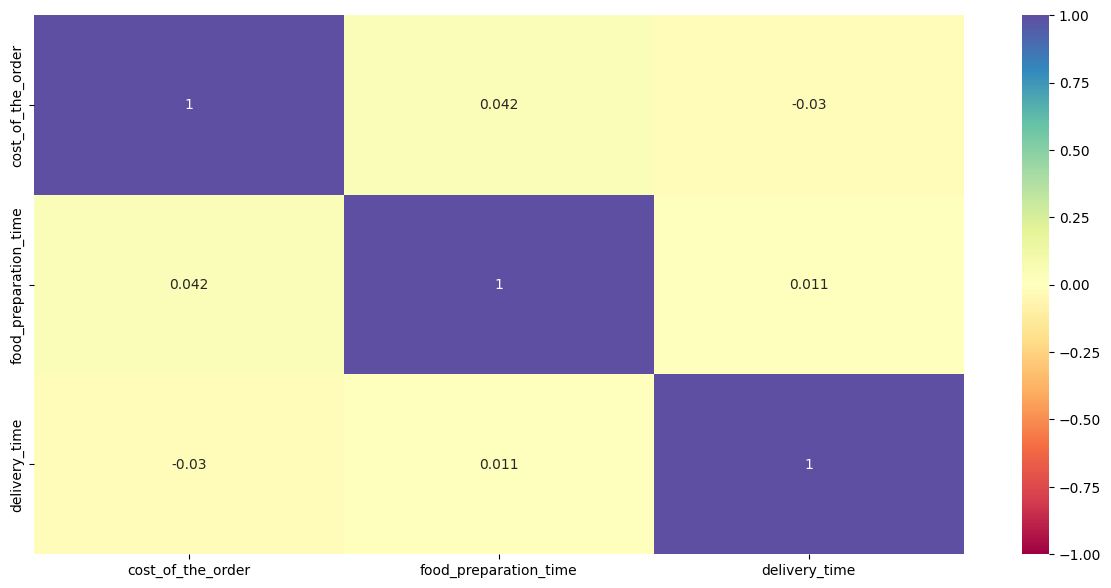

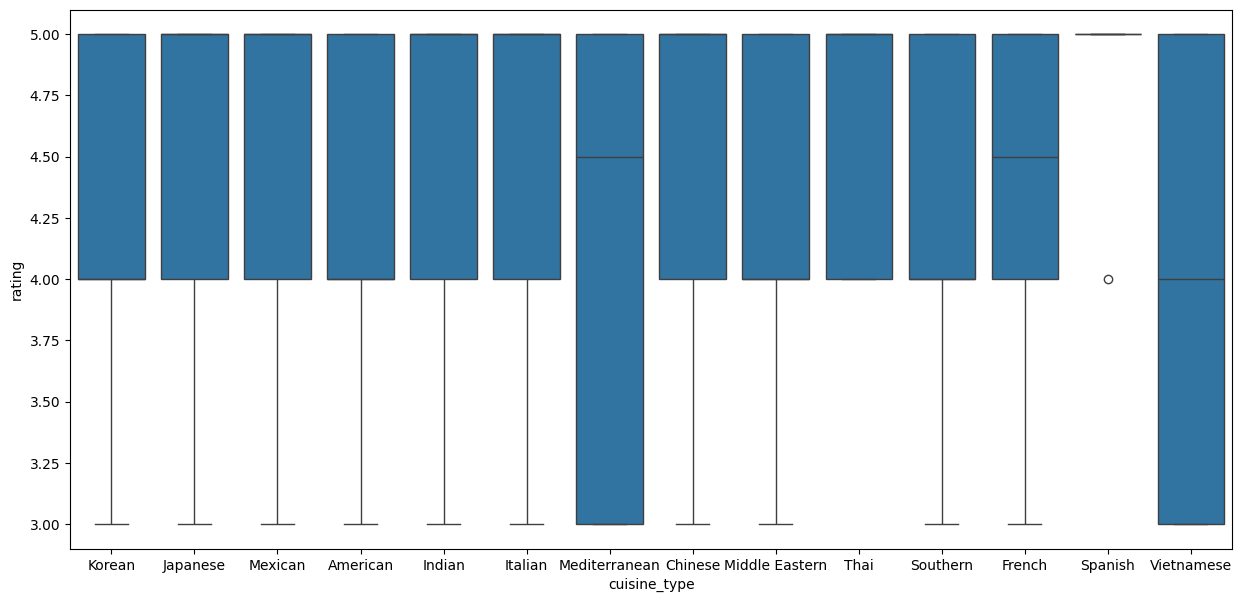

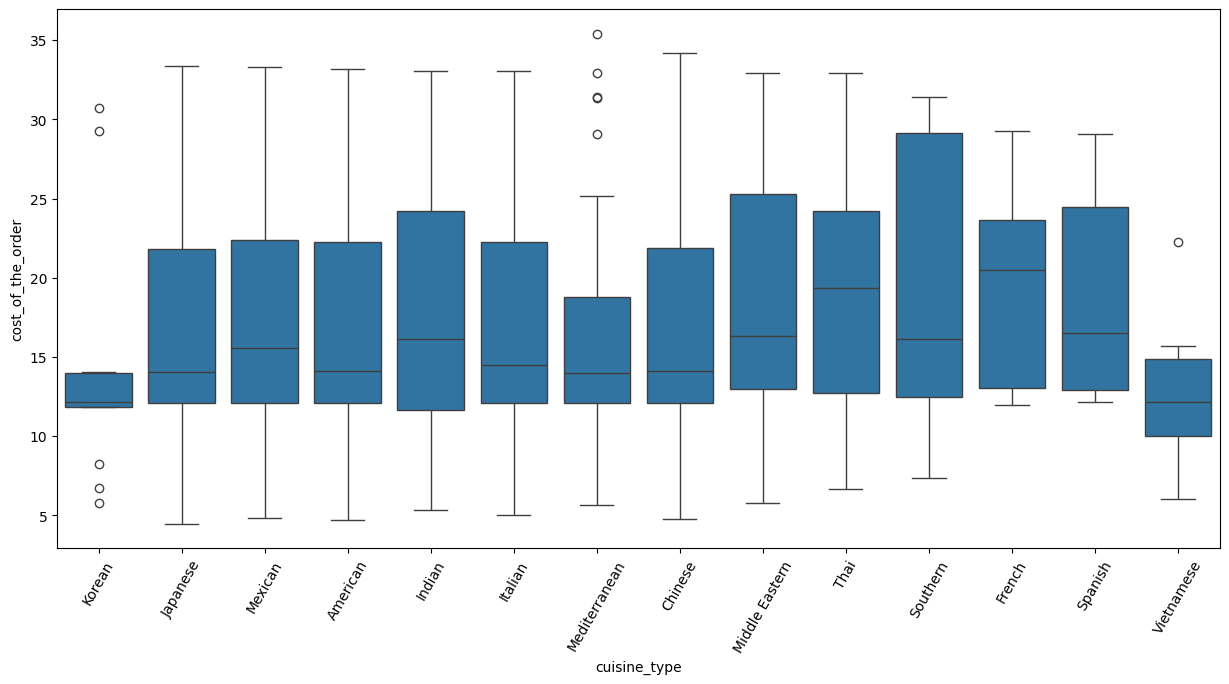

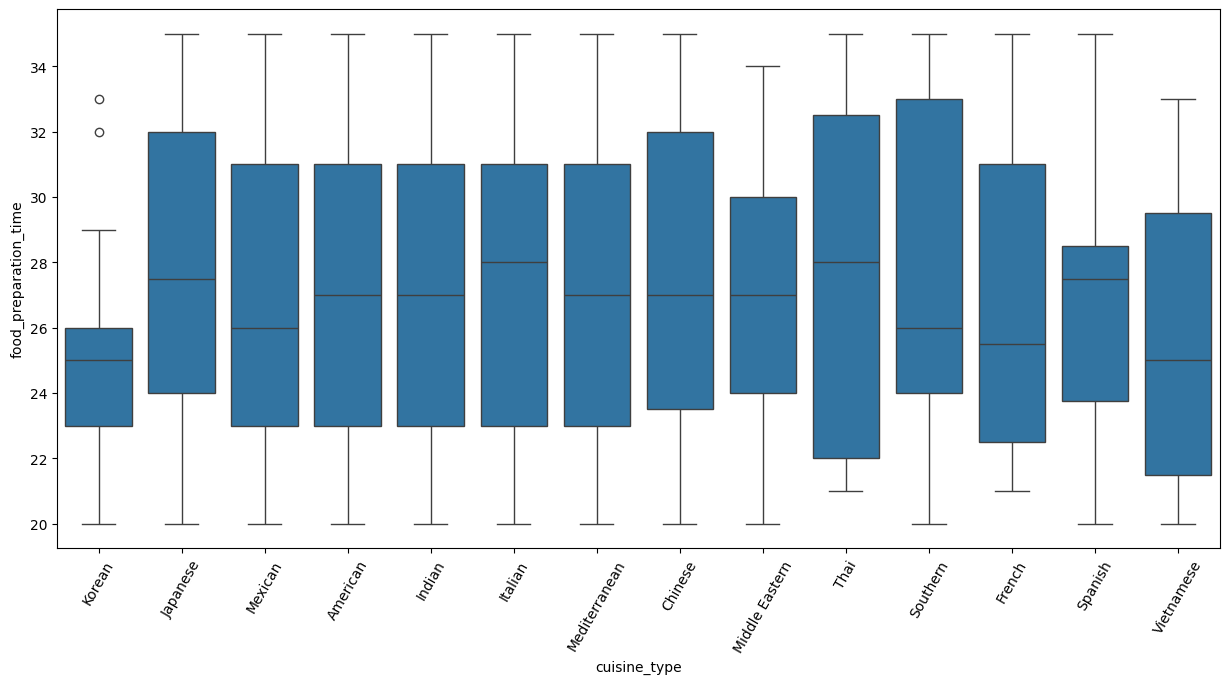

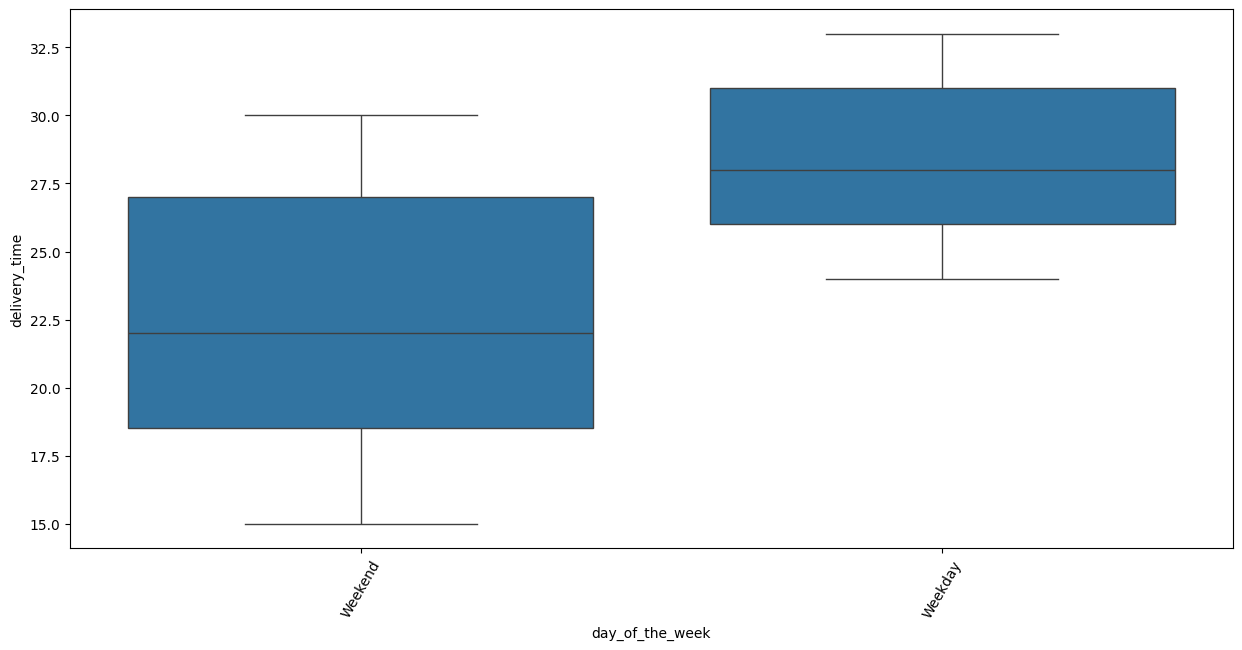

,cost_of_the_order
restaurant_name,
Shake Shack,3579.53
The Meatball Shop,2145.21
Blue Ribbon Sushi,1903.95
Blue Ribbon Fried Chicken,1662.29
Parm,1112.76
RedFarm Broadway,965.13
RedFarm Hudson,921.21
TAO,834.50
Han Dynasty,755.29


,cost_of_the_order
cuisine_type,
American,9530.78
Japanese,7663.13
Italian,4892.77
Chinese,3505.62
Mexican,1303.85
Indian,1235.14
Middle Eastern,922.21
Mediterranean,711.84
Thai,364.95


,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68
RedFarm Broadway,59
RedFarm Hudson,55
TAO,49
Han Dynasty,46


,count
cuisine_type,
American,584
Japanese,470
Italian,298
Chinese,215
Mexican,77
Indian,73
Middle Eastern,49
Mediterranean,46
Thai,19


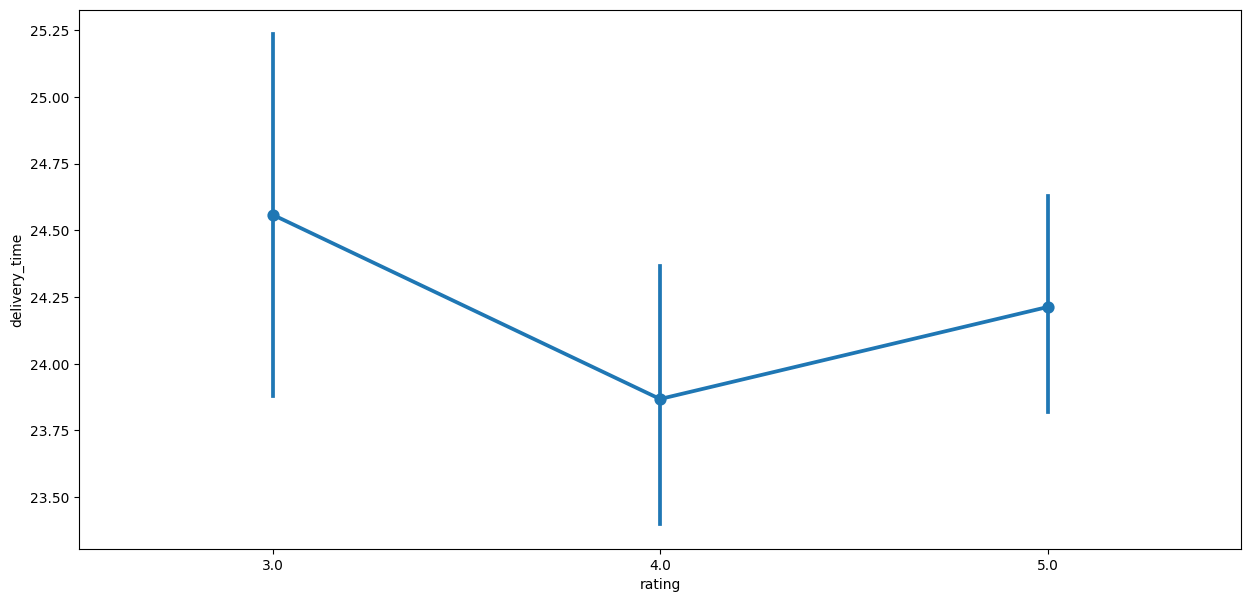

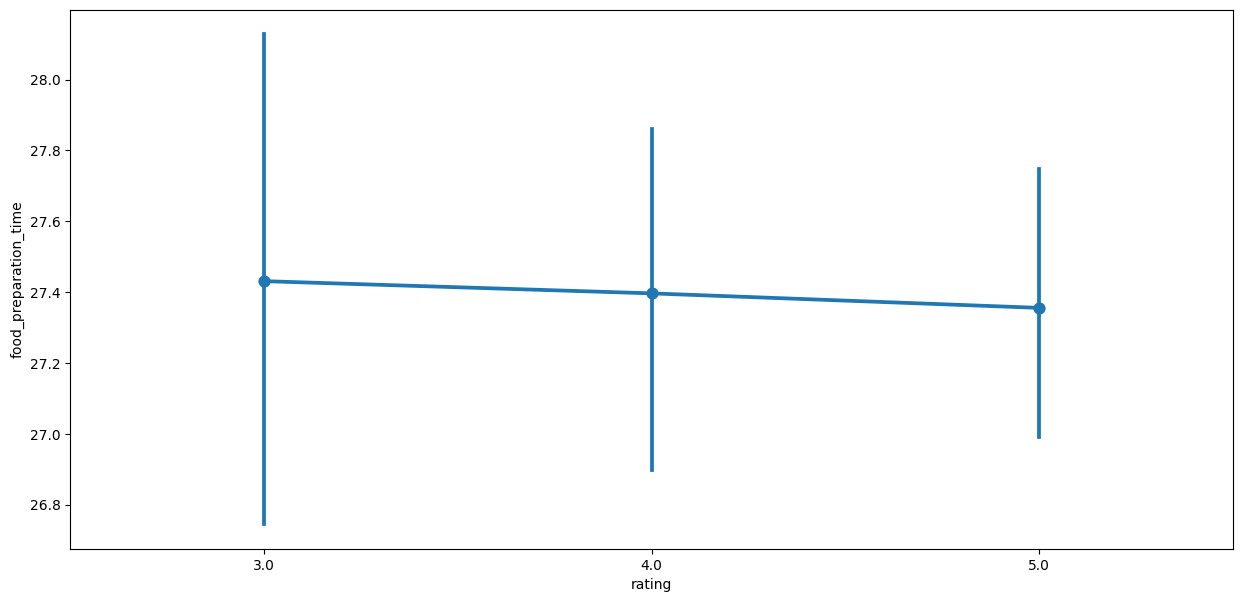

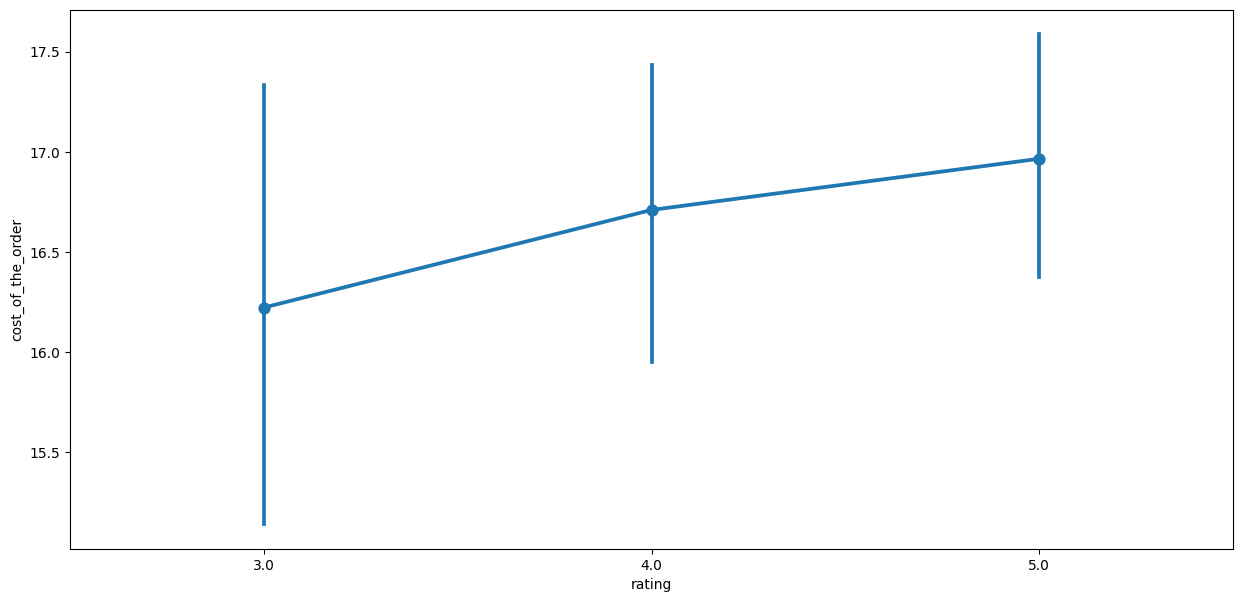

In [94]:
# Write the code here

# Heatmap finding the relation between cost, prep time, and delivery time
col_list = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']
plt.figure(figsize=(15,7))
sns.heatmap(data[col_list].corr(numeric_only=True),annot=True,cmap='Spectral',vmin=-1,vmax=1)
plt.show()
# Conlcusion: There is almost no correlation


# Finding the distribution of ratings for each cuisine type
plt.figure(figsize=(15,7))
sns.boxplot(data=data, x='cuisine_type', y='rating')
plt.show()
# Conclusion: They all seem pretty similar across the board except vietnemese and mediterranian are significantly lower rated than the others on average (although not poorly rated)
# and spanish is very highly rated, although that could be because of a small sample size. Spanish is the second lowest ordered cuisine type and vietnemese is the first.


# Finding the distribution of costs for each cuisine type
plt.figure(figsize=(15,7))
sns.boxplot(x = "cuisine_type", y = "cost_of_the_order", data = data)
plt.xticks(rotation = 60)
plt.show()
# Conclusion: Top contenders for most expensive food include french, southern, thai, and middle eastern. But southern has lower cost on average. It just can be more expensive in it's outliers.

# Finding the distribution of food prep times for each cuisine type
plt.figure(figsize=(15,7))
sns.boxplot(x = "cuisine_type", y = "food_preparation_time", data = data)
plt.xticks(rotation = 60)
plt.show()
# Conclusion: Thai, italian, and japanese take the longest on average, but southern can take the longest in the outliers.


# Finding the distribution of delivery times for both the weekend and weekday
plt.figure(figsize=(15,7))
sns.boxplot(x = "day_of_the_week", y = "delivery_time", data = data)
plt.xticks(rotation = 60)
plt.show()
# Conclusion: Delivery times are longer on the weekday. Interesting because there are more orders on the weekend. Maybe there are less drivers on weekdays
# because there are less orders, and that's why delivery times are longer.

# Finding the highest total revenue for each restaurant
display(data.groupby(['restaurant_name'])['cost_of_the_order'].sum().sort_values(ascending = False).head(14))
# Conclusion: The highest revanue restaurants are Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken, and Parm.

display(data.groupby(['cuisine_type'])['cost_of_the_order'].sum().sort_values(ascending = False).head(14))

# Finding the highest number of orders for each restaurant
display(data['restaurant_name'].value_counts().head(14))
# Conclusion: The highest number of orders very closly matches the highest revenue.

# Finding the total number of orders for each kind of cuisine
display(data['cuisine_type'].value_counts().head(14))
# Conclusion: American, Japanese, Italian, Chinese, Mexican

# Relationship between rating and delivery time
plt.figure(figsize=(15, 7))
sns.pointplot(x = 'rating', y = 'delivery_time', data = data)
plt.show()
# Conclusion: There is a very minor relationship

# Relationship between rating and food preparation time
plt.figure(figsize=(15, 7))
sns.pointplot(x = 'rating', y = 'food_preparation_time', data = data)
plt.show()
# Conclusion: There is a very minor relationship

# Relationship between rating and cost of the order
plt.figure(figsize=(15, 7))
sns.pointplot(x = 'rating', y = 'cost_of_the_order', data = data)
plt.show()
# There is a very minor relationship



### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [76]:
# Write the code here
data[data['rating'].isin([4.0,5.0])]["restaurant_name"].value_counts()[data[data['rating'].isin([4.0,5.0])]["restaurant_name"].value_counts() > 50]
# Conclusion: Shake Shack has the most 4 and 5 star ratings by far.

,count
restaurant_name,
Shake Shack,110
The Meatball Shop,74
Blue Ribbon Sushi,57
Blue Ribbon Fried Chicken,53


#### Observations:


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [77]:
# Write the code here
(data[data['cost_of_the_order'] > 20]['cost_of_the_order'] * .25).sum() + (data[(data['cost_of_the_order'] <= 20) & (data['cost_of_the_order'] > 5)]['cost_of_the_order'] * .15).sum()


np.float64(6166.303)

#### Observations:


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [78]:
# Write the code here
(len(data[data['delivery_time'] > 60])/len(data)) * 100

0.0

#### Observations:


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [79]:
# Write the code here
(data[data['day_of_the_week'] == "Weekday"]['delivery_time'].mean())/(data[data['day_of_the_week'] == "Weekend"]['delivery_time'].mean())




np.float64(1.2612375859508294)

#### Observations:


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

## Conclusions:
* Weekends have more orders than weekdays.
* Weekday delivery times are longer.
* Shake Shack is by far the most popular restaurant. The top 5 are Shake Shack,The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken, and Parm.
* The top five cuisine types for both revenue and number of orders are American, Japanese, Italian, Chinese, Mexican.
* Mexican seems to fall behind the others brutally. American has 584, Chinese has 215, and Mexican has 77.
* Delivery and meal prep times don't seem to affect ratings that much. Maybe very slightly.


### Recommendations:

* Incentivise drivers to drive on weekends.
* Figure out why weekday delivery times are longer.
* Work with Shake Shake, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken, and Parm.
* Figure out what Shake Shack is doing to perform so well on uber and reward other restaurants for doing the same. It could just be that they are popular, though.
* Work with more american, japanese, Italian, and Chinese restaurants.
* Maybe consider slightly prioritizing other things besides delivery times and testing if that improves overall revenue and customer satisfaction. Take this one with a grain of salt. It could be that the variance between delivery times and meal prep times is just not that large, and that's why they don't seem to have much of an affect on ratings.

---